In [1]:
import pandas as pd
import numpy as np
import torch
import importlib
from importlib import reload
import os
import sys
sys.path.append(os.path.abspath('../'))
from IMOD_Protocols import ScoreSpectra, BayesianOptimization,GaussianProcess, PlotGP, MaraData,TxtToCsvConverter
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from scipy.stats import qmc
import random

dtype = torch.float64

In [2]:
# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N2 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 1.00,  
                  'R MAI': 1.50,
                  'R PbI2': 1,
                  }

# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N1 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 2.00,  
                  'R MAI': 2.00,
                  'R PbI2': 1,
                  }

# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N3 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 0.667,  # aprox to 0.675
                  'R MAI': 1.333, # aprox to 1.325
                  'R PbI2': 1,
                  }

theoretical_N4 = {'Anneal Time': 10, # min
                  'Temperature': 95, # C
                  'R BAAc': 0.5,  
                  'R MAI': 1.25,
                  'R PbI2': 1,
                  }

In [3]:
N1_data = pd.read_csv('N1_Sep/Data/N1Campaign_data.csv')
N2_data = pd.read_csv('N2_Sep/Data/N2Campaign_data.csv')
N3_data = pd.read_csv('N3_New/Data/N3Campaign_data.csv')

In [4]:
# vals_per_round = [N1_data[:36], N1_data[37:36+12], N1_data[49:73]]

# for i in range (len(vals_per_round)):
#     x = np.full(len(vals_per_round[i]), i)
#     plt.scatter(x, vals_per_round[i]['QW 1'], alpha=0.7, color='tab:blue')
#     if i == 2:
#         plt.xticks(range(3), [f'Round {j}' for j in range(3)])
#         plt.ylabel('QW 1')
#         plt.title('Vertical plot of QW 1 per round')
#         plt.grid(True)
#         plt.show()



In [5]:
# 2D GP of the stoicheometry
def data_prep(data, QW_num):
    # Past experimental data loading
    previous_data = data[['Anneal Time','Temperature','R BAAc', 'R MAI', 'R PbI2', f'{QW_num}']]
    data_df = previous_data[['Anneal Time','R PbI2','R BAAc', 'R MAI', 'Temperature']][::2].reset_index(drop=True)

    QW_mean = previous_data[f'{QW_num}'].groupby(previous_data.index // 2).mean().reset_index(drop=True)
    QW_var = previous_data[f'{QW_num}'].groupby(previous_data.index // 2).var().reset_index(drop=True)
    data_df[f'{QW_num} mean'] = QW_mean
    data_df[f'{QW_num} var'] = QW_var

    return data_df

    # fig, axs = plt.subplots(1, 4, figsize=(15, 3))
    # variables = ['Anneal Time', 'Temperature', 'R BAAc', 'R MAI']
    # titles = ['Anneal Time vsf {QW_num}', 'Temp vsf {QW_num}', 'R BAAc vsf {QW_num}', 'R MAI vsf {QW_num}']

    # for ax, var, title in zip(axs.flatten(), variables, titles):
    #     scatter = ax.scatter(R0_df[var], R0_df[f'{QW_num} mean'], c=R0_df[f'{QW_num} mean'], cmap='viridis', label='mean')
    #     ax.errorbar(R0_df[var], R0_df[f'{QW_num} mean'], yerr=R0_df[f'{QW_num} var']**0.5, fmt='none', ecolor='gray', alpha=0.5)
    #     ax.set_xlabel(var)
        
    #     ax.set_title(title)
    #     plt.colorbar(scatter, ax=ax, label=f'{QW_num} mean')

    # plt.tight_layout()
    # plt.show()

def gp_stoich(data_df, QW_num, bounds):
    dtype = torch.float64
    original_bounds = torch.tensor([[0.40, 1.1],[1.2, 1.6]], dtype=dtype) #  R BAAc, R MAI

    # Set up of the traning data
    train_X = data_df[['R BAAc', 'R MAI']].to_numpy()
    train_y = data_df[f'{QW_num} mean'].to_numpy()
    train_yvar = data_df[f'{QW_num} var'].to_numpy() # Use the mean off {QW_num} for training

    gaussian = GaussianProcess(train_X, train_y, train_yvar=train_yvar,bounds = original_bounds.T)
    gaussian.fit()

    gaussian.evaluate()

def gp_process(data_df, QW_num):
    dtype = torch.float64
    original_bounds = torch.tensor([[5, 60], [60, 150]], dtype=dtype) #  R BAAc, R MAI

    # Set up of the traning data
    train_X = data_df[['Anneal Time','Temperature']].to_numpy()
    train_y = data_df[f'{QW_num} mean'].to_numpy()
    train_yvar = data_df[f'{QW_num} var'].to_numpy() # Use the mean off {QW_num} for training

    gaussian = GaussianProcess(train_X, train_y, train_yvar=train_yvar,bounds = original_bounds.T)
    gaussian.fit()




In [ ]:
from matplotlib import animation
from IPython.display import HTML
import matplotlib as mpl
import matplotlib, IPython
import itertools
from matplotlib.animation import FFMpegWriter


def plot_gp_surface(data, bounds, qw_col, title_suffix='', train_type = 'stoich'):
    if train_type == 'stoich':
        columns = ['R BAAc', 'R MAI']
    elif train_type == 'process':
        columns = ['Anneal Time', 'Temperature']

    bounds = bounds.T

    data['round'] = data['files'].str.extract(r'R(\d+)', expand=False).astype(int)

    # optional: inspect counts per round to verify R0 has 18 points
    print("counts per round:\n", data['round'].value_counts().sort_index())

    groups = [g for _, g in data.groupby('round', sort=True)]

    data_train = data_prep(data, qw_col)

    x = np.linspace(0, 1, 50)
    y = np.linspace(0, 1, 50)
    X, Y = np.meshgrid(x, y)
    XY = np.c_[X.ravel(), Y.ravel()]

    fig, ax = plt.subplots(figsize=(6, 5))
    start = 0
    artists = []
    last_cf = None
    for idx, g in enumerate(groups):
        start += len(g)//2 

        train_X = data_train[columns][:start].to_numpy()
        train_y = data_train[f'{qw_col} mean'][:start].to_numpy()
        train_yvar = data_train[f'{qw_col} var'][:start].to_numpy()

        print(train_X.shape, train_y.shape, train_yvar.shape)

        gp = GaussianProcess(train_X, train_y, train_yvar=train_yvar,bounds=bounds)
        gp.fit()

        # Generate meshgrid for contour
        z = gp.evaluate(XY)[0].reshape(X.shape)

        frame_artists = []
        
        cf = ax.contourf(X, Y, z, levels=50, cmap='viridis', vmin=0, vmax=0.5)
        frame_artists.extend(cf.collections)  

        if idx == 0:
            pts =  ax.scatter(
            (train_X[:, 0] - bounds[0, 0].item()) / (bounds[1, 0].item() - bounds[0, 0].item()),
            (train_X[:, 1] - bounds[0, 1].item()) / (bounds[1, 1].item() - bounds[0, 1].item()),
            marker = 'x', color='r', s=80, alpha=0.9)
            frame_artists.append(pts)
        else:
            # Optional: overlay training points
            pts =  ax.scatter(
                (train_X[:, 0] - bounds[0, 0].item()) / (bounds[1, 0].item() - bounds[0, 0].item()),
                (train_X[:, 1] - bounds[0, 1].item()) / (bounds[1, 1].item() - bounds[0, 1].item()),
                marker = '.',color='k', s=80, alpha=0.5
            )
            ax.legend()
            frame_artists.append(pts)

        artists.append(frame_artists)
        last_cf = cf
        frame_artists.append(pts)
        
    # plt.colorbar(cf, ax=ax, label='Predicted QW 1')

    if last_cf is not None:
        plt.colorbar(last_cf, ax=ax, label=f'Predicted {qw_col}')
    
    # Set ticks and labels for unnormalized axis
    xticks = np.linspace(0, 1, 5)
    xticklabels = np.round(
        bounds[0, 0].item() + xticks * (bounds[1, 0].item() - bounds[0, 0].item()), 2
    )
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    yticks = np.linspace(0, 1, 5)
    yticklabels = np.round(
        bounds[0, 1].item() + yticks * (bounds[1, 1].item() - bounds[0, 1].item()), 2
    )
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    ax.set_xlabel('R BAAc')
    ax.set_ylabel('R MAI')
    ax.set_title(title_suffix)


    # ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=400)
    ani = animation.ArtistAnimation(fig, artists=artists, interval=400, blit=False, repeat_delay=800)
    plt.tight_layout()
    # HTML(ani.to_jshtml())
    return HTML(ani.to_jshtml()), ani


counts per round:
 round
0    54
1    12
2    12
Name: count, dtype: int64
(27, 2) (27,) (27,)
(33, 2) (33,) (33,)


/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/3924450385.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/3924450385.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_art

(39, 2) (39,) (39,)


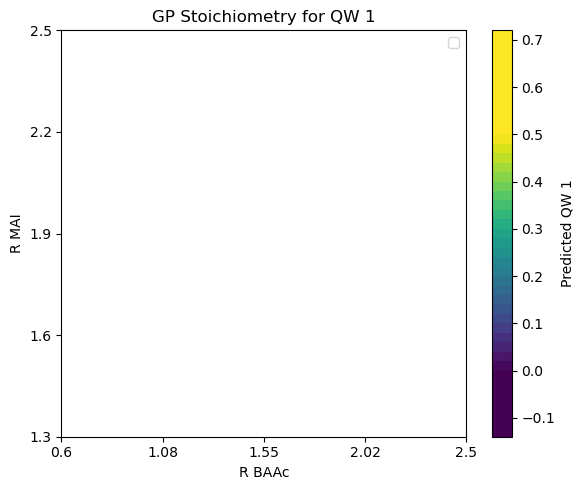

In [64]:
N1_bounds = torch.tensor([[0.6, 2.5],[1.3, 2.5]], dtype=dtype) #  R BAAc, R MAI
_, N1_ani_s = plot_gp_surface(N1_data, N1_bounds,'QW 1', title_suffix='GP Stoichiometry for QW 1', train_type='stoich')
# assuming you have `ani` from FuncAnimation/ArtistAnimation
writer = FFMpegWriter(fps=2, bitrate=1800, metadata={'artist':'you'})
N1_ani_s.save("N1_GP_stoich.mp4", writer=writer, dpi=150)
_

counts per round:
 round
0    54
1    12
2    12
Name: count, dtype: int64
(27, 2) (27,) (27,)


/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Round

(33, 2) (33,) (33,)
(39, 2) (39,) (39,)


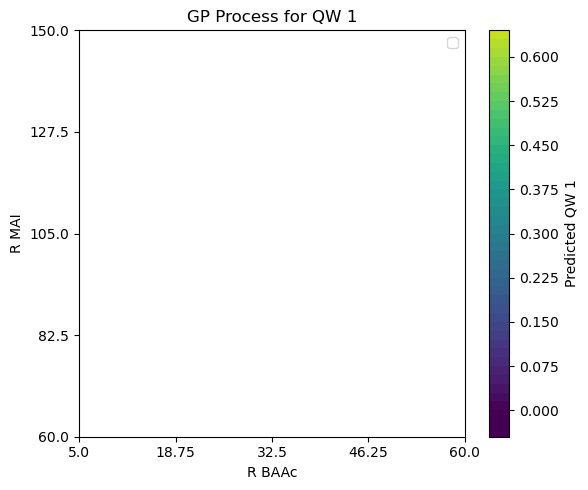

In [8]:
N1_bounds = torch.tensor([[5, 60], [60, 150]], dtype=dtype) 
_, N1_ani_s = plot_gp_surface(N1_data, N1_bounds,'QW 1', title_suffix='GP Process for QW 1', train_type='process')

# assuming you have `ani` from FuncAnimation/ArtistAnimation
writer = FFMpegWriter(fps=2, bitrate=1800, metadata={'artist':'you'})
N1_ani_s.save("N1_GP_process.mp4", writer=writer, dpi=150)
_

counts per round:
 round
0     36
1     12
2     12
3     12
4     12
5     24
7     12
8     12
9     12
10    12
11    24
13    12
14    12
15    12
Name: count, dtype: int64
(18, 2) (18,) (18,)


/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Round

(24, 2) (24,) (24,)
(30, 2) (30,) (30,)
(36, 2) (36,) (36,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(42, 2) (42,) (42,)
(54, 2) (54,) (54,)


...

/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(90, 2) (90,) (90,)
(96, 2) (96,) (96,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(102, 2) (102,) (102,)
(108, 2) (108,) (108,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

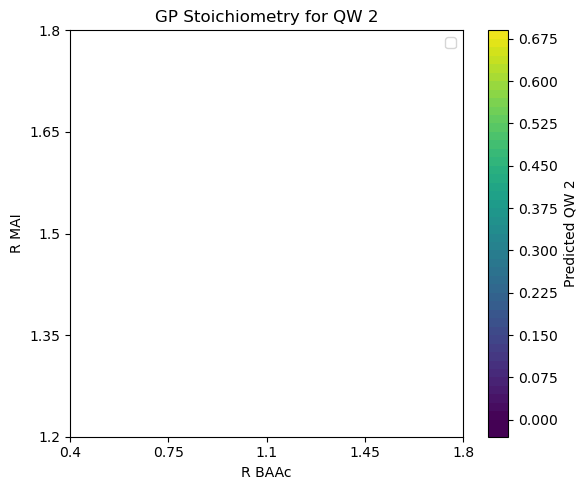

In [9]:
N2_bounds = torch.tensor([[0.40, 1.8],[1.2, 1.8]], dtype=dtype) #  R BAAc, R MAI

_, N2_ani_s = plot_gp_surface(N2_data, N2_bounds,'QW 2', title_suffix='GP Stoichiometry for QW 2', train_type='stoich')
# assuming you have `ani` from FuncAnimation/ArtistAnimation
writer = FFMpegWriter(fps=2, bitrate=1800, metadata={'artist':'you'})
N2_ani_s.save("N2_GP_stoich.mp4", writer=writer, dpi=150)
_

counts per round:
 round
0     36
1     12
2     12
3     12
4     12
5     24
7     12
8     12
9     12
10    12
11    24
13    12
14    12
15    12
Name: count, dtype: int64
(18, 2) (18,) (18,)
(24, 2) (24,) (24,)


/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Round

(30, 2) (30,) (30,)
(36, 2) (36,) (36,)
(42, 2) (42,) (42,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(54, 2) (54,) (54,)
(60, 2) (60,) (60,)


...

/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(96, 2) (96,) (96,)
(102, 2) (102,) (102,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(108, 2) (108,) (108,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


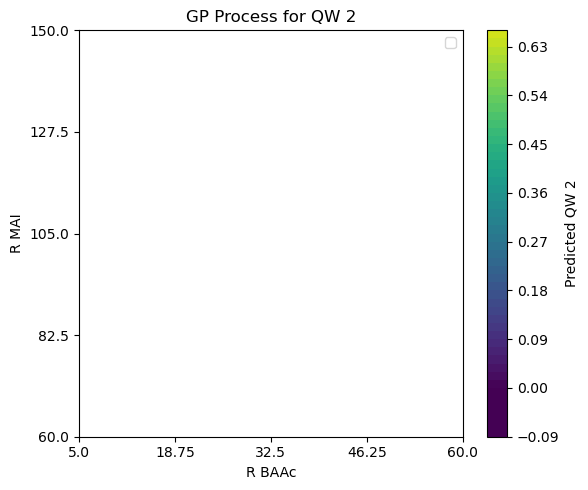

In [10]:
N2_bounds = torch.tensor([[5, 60], [60, 150]], dtype=dtype) #  R BAAc, R MAI

_, N2_ani_s = plot_gp_surface(N2_data, N2_bounds,'QW 2', title_suffix='GP Process for QW 2', train_type='process')
# assuming you have `ani` from FuncAnimation/ArtistAnimation
writer = FFMpegWriter(fps=2, bitrate=1800, metadata={'artist':'you'})
N2_ani_s.save("N2_GP_process.mp4", writer=writer, dpi=150)
_


In [11]:
# N2_bounds = torch.tensor([[0.40, 1.8],[1.2, 1.8]], dtype=dtype) #  R BAAc, R MAI
# # Select data for this time/temp
# N2_data_train = data_prep(N2_data, 'QW 2')
# train_X = N2_data_train[['R BAAc', 'R MAI']].to_numpy()
# train_y = N2_data_train['QW 2 mean'].to_numpy()
# train_yvar = N2_data_train['QW 2 var'].to_numpy()
# plot_gp_surface(train_X, train_y, N2_bounds, title_suffix='GP Predicted Surface for QW 2')

# N2_bounds = torch.tensor([[5, 60], [60, 150]], dtype=dtype) #  R BAAc, R MAI
# train_X = N2_data_train[['Anneal Time', 'Temperature']].to_numpy()
# train_y = N2_data_train['QW 2 mean'].to_numpy()
# train_yvar = N2_data_train['QW 2 var'].to_numpy()
# plot_gp_surface(train_X, train_y, N2_bounds, title_suffix='GP Predicted Surface for QW 2')


counts per round:
 round
0    54
1    12
2    12
3    12
4    12
5    12
6    12
7    12
8    12
9    12
Name: count, dtype: int64
(27, 2) (27,) (27,)
(33, 2) (33,) (33,)
(39, 2) (39,) (39,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(45, 2) (45,) (45,)
(51, 2) (51,) (51,)
(57, 2) (57,) (57,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(63, 2) (63,) (63,)
(69, 2) (69,) (69,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(75, 2) (75,) (75,)
(81, 2) (81,) (81,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


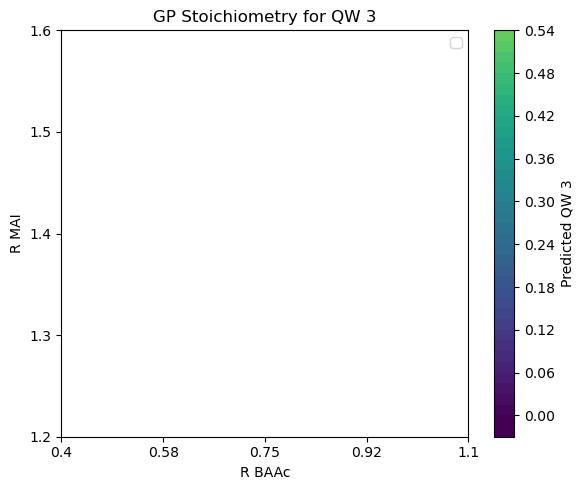

In [12]:
N3_bounds = torch.tensor([[0.40, 1.1],[1.2, 1.6]], dtype=dtype) #  R BAAc, R MAI

_, N3_ani_s = plot_gp_surface(N3_data, N3_bounds,'QW 3', title_suffix='GP Stoichiometry for QW 3', train_type='stoich')
# assuming you have `ani` from FuncAnimation/ArtistAnimation
writer = FFMpegWriter(fps=2, bitrate=1800, metadata={'artist':'you'})
N3_ani_s.save("N3_GP_stoich.mp4", writer=writer, dpi=150)
_

counts per round:
 round
0    54
1    12
2    12
3    12
4    12
5    12
6    12
7    12
8    12
9    12
Name: count, dtype: int64
(27, 2) (27,) (27,)
(33, 2) (33,) (33,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(39, 2) (39,) (39,)
(45, 2) (45,) (45,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

(51, 2) (51,) (51,)
(57, 2) (57,) (57,)
(63, 2) (63,) (63,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend

(69, 2) (69,) (69,)
(75, 2) (75,) (75,)
(81, 2) (81,) (81,)


/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.extend(cf.collections)
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/ctuwsunlab/Documents/Sun_Lab/.conda/lib/python3.11/site-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
/var/folders/w5/97kpzvwd275ccm0x7kqfrby00000gn/T/ipykernel_23345/953933389.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  frame_artists.exten

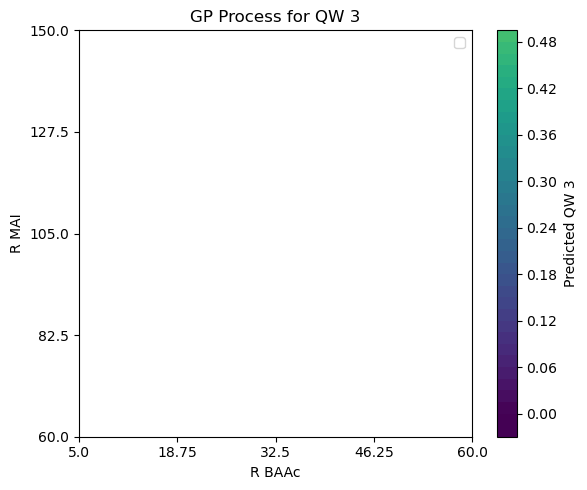

In [13]:
N3_bounds = torch.tensor([[5, 60], [60, 150]], dtype=dtype) #  R BAAc, R MAI

_, N3_ani_s = plot_gp_surface(N3_data, N3_bounds,'QW 3', title_suffix='GP Process for QW 3', train_type='process')
# assuming you have `ani` from FuncAnimation/ArtistAnimation
writer = FFMpegWriter(fps=2, bitrate=1800, metadata={'artist':'you'})
N3_ani_s.save("N3_GP_process.mp4", writer=writer, dpi=150)
_
